# Part IV: Elastic Net Regression using Gradient Descent

In [51]:
# 1. Imported required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

### Reusing Part 1 code with little modification to work for this

In [52]:
# Reused class from Part 1
class PreprocessPipeline:
    def __init__(self, paths, one_hot_cols=None, label_encode_cols=None):
        # Initialize the values that would be needed in other funtions so we dont have to send the value again and again while calling the function
        self.paths = paths
        self.df = None
        self.one_hot_cols = one_hot_cols if one_hot_cols else []
        self.label_encode_cols = label_encode_cols if label_encode_cols else []

    # Modified so It can take more then one csv and concat it
    def load_data(self):
        dfs = [pd.read_csv(path, sep=';') for path in self.paths]
        self.df = pd.concat(dfs, ignore_index=True)
        return self.df

    def handle_missing(self):
      # Found the threshold and if the nan value is below it then drop that
        self.df = self.df.dropna(thresh=len(self.df.columns)//2)
        for col in self.df.select_dtypes(include=["object"]).columns:
            self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
        for col in self.df.select_dtypes(include=["int64","float64"]).columns:
            self.df[col] = self.df[col].fillna(self.df[col].median())

    def handle_outliers(self):
      # Used IQR method to handel outliers
        for col in self.df.select_dtypes(include=["int64","float64"]).columns:
            Q1, Q3 = self.df[col].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
            self.df[col] = np.clip(self.df[col], lower, upper)

    def encode_categoricals(self):
      # Encoded by Onehot method for any column and if not given then by default for penguin dataset did for gender.
        if self.one_hot_cols:
            self.df = pd.get_dummies(self.df, columns=self.one_hot_cols, drop_first=True)
        if self.label_encode_cols:
            for col in self.label_encode_cols:
                self.df[col] = self.df[col].astype('category').cat.codes

    def visualizeData(self):
      # Visualize the dataset genericly
        numeric_df = self.df.select_dtypes(include=["float64","int64"])
        if numeric_df.shape[1] > 0:
            plt.figure(figsize=(10,6))
            sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
            plt.title("Correlation Heatmap")
            plt.show()
            numeric_df.hist(figsize=(12,10))
            plt.show()
            for col in numeric_df.columns[:3]:
                sns.boxplot(x=numeric_df[col])
                plt.show()

    def fit_transform(self):
      # Called all the function in one place
        self.load_data()
        self.handle_missing()
        self.handle_outliers()
        self.encode_categoricals()
        self.visualizeData()
        return self.df

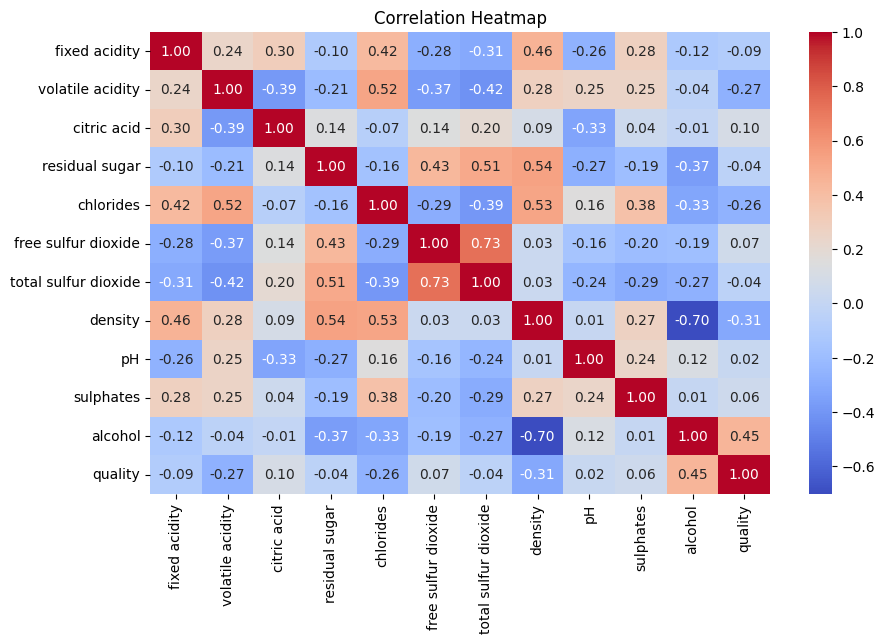

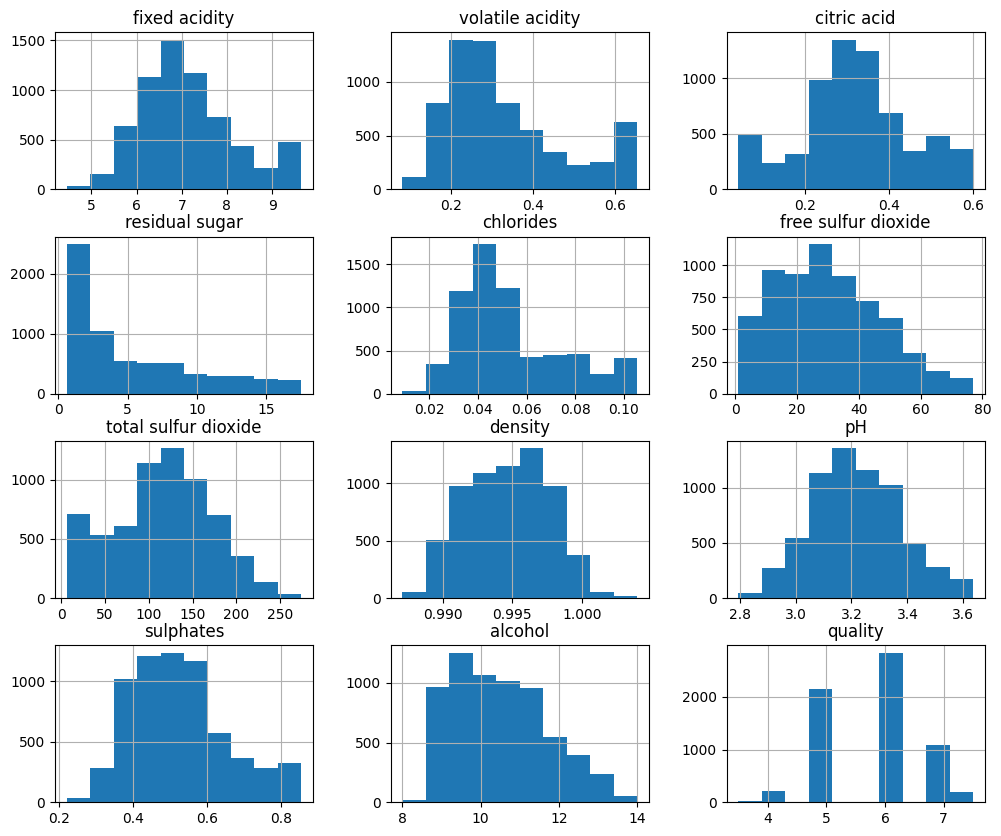

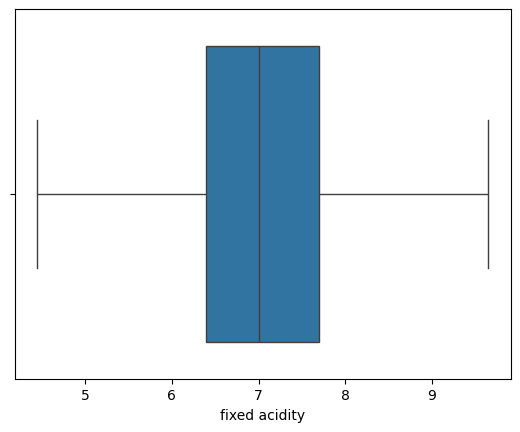

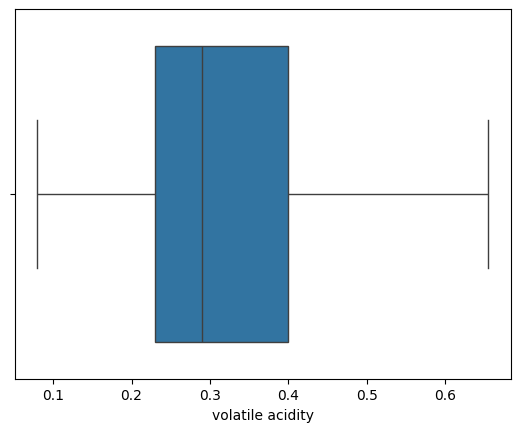

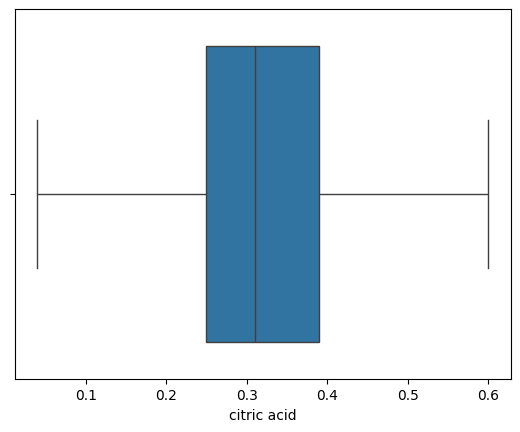

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.142173,0.332612,0.316180,5.407727,0.053230,30.339541,115.671926,0.994689,3.217638,0.526667,10.491624,5.804679
std,1.066080,0.144376,0.131856,4.613702,0.021289,16.904806,56.256191,0.002942,0.157901,0.131196,1.192136,0.829169
min,4.450000,0.080000,0.040000,0.600000,0.009000,1.000000,6.000000,0.987110,2.795000,0.220000,8.000000,3.500000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,9.650000,0.655000,0.600000,17.550000,0.105500,77.000000,274.500000,1.003965,3.635000,0.855000,14.000000,7.500000


In [53]:
# Using Wine csv's and cleaning by using Part 1 code with modified load data
paths = ["winequality-white.csv", "winequality-red.csv"]
pipeline = PreprocessPipeline(paths)
df = pipeline.fit_transform()
df.describe()

Describe Dataset: The dataset contains 6,497 wine samples, collected from both red and white wine varieties. Each sample is described by 11 numerical features.

1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol

and Target feature is (Y):
1. quality

In [54]:
# Setting target as Quality for this df
target_col = "quality"
#Creatng X and Y based in target
X = df.drop(columns=[target_col]).values
y = df[target_col].values.reshape(-1,1)

# Using random seed to standardize the randomness
np.random.seed(42)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
# Splitting into 80% and 20% for test and train
split_idx = int(0.8 * len(indices))

X_train, y_train = X[indices[:split_idx]], y[indices[:split_idx]]
X_test, y_test = X[indices[split_idx:]], y[indices[split_idx:]]

# Computing mean and standard deviation
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)

# Scale training and test features
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# scale target variable
y_mean, y_std = y_train.mean(), y_train.std()
y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

print("\nTrain/Test shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("------ y_train:", y_train.min(), y_train.max(), y_train.mean())
print("------ y_test:", y_test.min(), y_test.max(), y_test.mean())


Train/Test shapes:
X_train: (5197, 11) y_train: (5197, 1)
X_test: (1300, 11) y_test: (1300, 1)
------ y_train: -2.781199074318463 2.049243431900286 -1.0254128378296617e-16
------ y_test: -2.781199074318463 2.049243431900286 0.00977486989965842


In [55]:
def init_weights(method, input_dim):
    # Initialize weights using given 3 methods
    if method == "random":
        return np.random.randn(input_dim, 1) * 0.01
    elif method == "zero":
        return np.zeros((input_dim, 1))
    elif method == "xavier":
        limit = np.sqrt(6 / input_dim)
        return np.random.uniform(-limit, limit, (input_dim, 1))
    else:
        return np.random.randn(input_dim, 1) * 0.01

In [56]:
# Perform Elastic Net regression using Gradient Descent
def elastic_net_gradient_descent(X, y, alpha=0.001, lambda1=0.01, lambda2=0.001,
                                 max_iter=100000, tol=None, init_method="random"):
    N, d = X.shape
    w = init_weights(init_method, d)
    loss_history = []

    for i in range(max_iter):
        y_pred = X.dot(w)
        error = y_pred - y
        grad = (1/N) * (X.T.dot(error)) + lambda1*w + lambda2*np.sign(w)
        # Weights update
        w -= alpha * grad
        # loss cal
        loss = (1/(2*N))*np.sum(error**2) + (lambda1/2)*np.sum(w**2) + lambda2*np.sum(np.abs(w))
        loss_history.append(loss)

        # Early stopping if gradient small
        if tol is not None and np.all(np.abs(grad) < tol):
            print(f"{init_method} initialization: early stopping at iteration {i+1}")
            break

    return w, loss_history

In [57]:
#fucntion to calcualte the mean
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# function to calculate r^2
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

### **Early Stopping**

Early stopping mainly helped to stop overfitting by ending the training when loss didnt improve much.
When grad tolerance was used, the model stopped when update weights become very small.
The MSE and R² were almost same on training and testing data, so model was not overfitted.

In [58]:
# Initializing with diff settings
init_methods = ["random", "zero", "xavier"]
stopping_criteria = [
    {"name":"fixed_iter", "max_iter":10000, "tol":None},
    {"name":"grad_tol", "max_iter":100000, "tol":1e-4}
]

results = {}
best_weights = None
best_test_mse = float('inf')

In [59]:
# calling for all diff mwthods and stopping criteria one by one
for init in init_methods:
    for stop in stopping_criteria:
        w, loss_hist = elastic_net_gradient_descent(
            X_train, y_train, alpha=0.001, lambda1=0.01, lambda2=0.001,
            max_iter=stop["max_iter"], tol=stop["tol"], init_method=init
        )

        y_train_pred = X_train.dot(w)
        y_test_pred = X_test.dot(w)
        mse_train = mean_squared_error(y_train, y_train_pred)
        mse_test = mean_squared_error(y_test, y_test_pred)
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)

        results[(init, stop["name"])] = {
            "weights": w,
            "loss_history": loss_hist,
            "mse_train": mse_train,
            "mse_test": mse_test,
            "r2_train": r2_train,
            "r2_test": r2_test
        }

        print(f"\nInit: {init}, Stop: {stop['name']}")
        print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
        print(f"Train R2: {r2_train:.4f}, Test R2: {r2_test:.4f}")

        if mse_test < best_test_mse:
            best_test_mse = mse_test
            best_weights = w


Init: random, Stop: fixed_iter
Train MSE: 0.6984, Test MSE: 0.7174
Train R2: 0.3016, Test R2: 0.2914
random initialization: early stopping at iteration 77912

Init: random, Stop: grad_tol
Train MSE: 0.6979, Test MSE: 0.7174
Train R2: 0.3021, Test R2: 0.2913

Init: zero, Stop: fixed_iter
Train MSE: 0.6984, Test MSE: 0.7174
Train R2: 0.3016, Test R2: 0.2913
zero initialization: early stopping at iteration 77003

Init: zero, Stop: grad_tol
Train MSE: 0.6979, Test MSE: 0.7174
Train R2: 0.3021, Test R2: 0.2913

Init: xavier, Stop: fixed_iter
Train MSE: 0.6979, Test MSE: 0.7185
Train R2: 0.3021, Test R2: 0.2902
xavier initialization: early stopping at iteration 92210

Init: xavier, Stop: grad_tol
Train MSE: 0.6979, Test MSE: 0.7174
Train R2: 0.3021, Test R2: 0.2913


### Discuss and analyze: Experiments conducted with different initialization methods [Random, Zero, and Xavier] and 2 stopping criteria

1. Speed of Convergence:
The Random and Zero initialization methods converged faster compared to Xavier initialization.

2. Final Loss:
All three initialization methods achieved very similar final loss and R² values.

3. Stability of Training:


*   The Zero initialization was stable but took more iterations in some runs.
*   The Random initialization was also stable and gave consistent results
*   The Xavier initialization worked but did not outperform

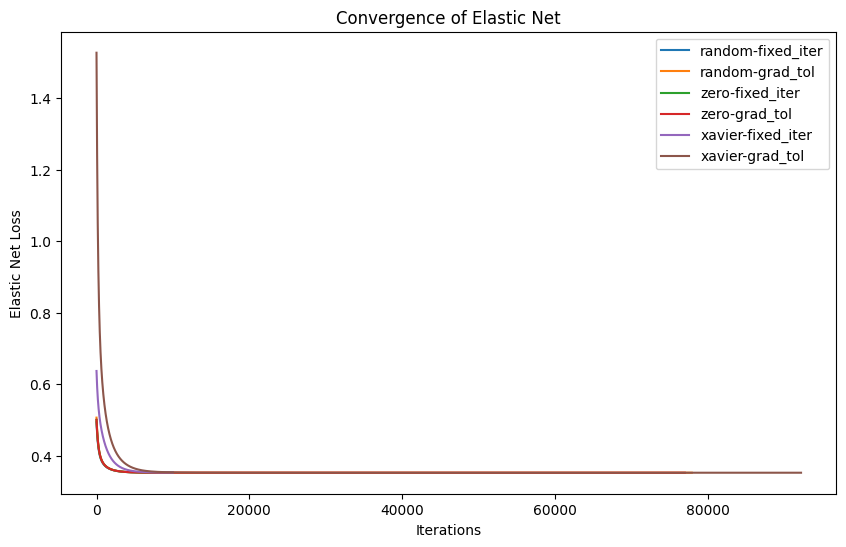

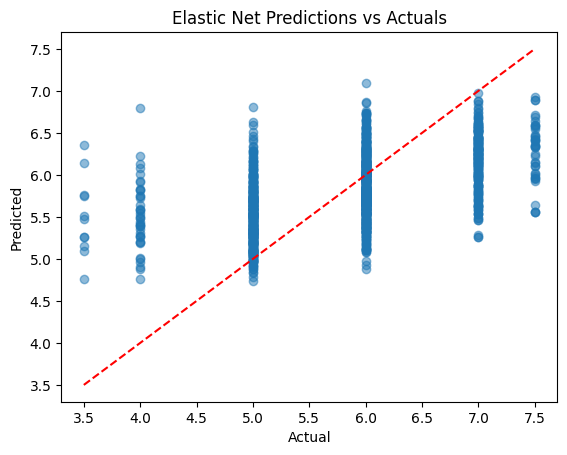

Best weights saved as a1_part_4_weights_Rajagop6_ Raviraja.pkl


In [60]:
# Plotting graph to show Convergence plots (loss vs iterations)
plt.figure(figsize=(10,6))
for key in results:
    plt.plot(results[key]["loss_history"], label=f"{key[0]}-{key[1]}")
plt.xlabel("Iterations")
plt.ylabel("Elastic Net Loss")
plt.title("Convergence of Elastic Net")
plt.legend()
plt.show()

# Plotting Graph for predictions vs. actuals (scatter with y=x line)
y_test_pred = X_test.dot(best_weights)
plt.scatter(y_test * y_std + y_mean, y_test_pred * y_std + y_mean, alpha=0.5)
plt.plot([y_test.min()*y_std + y_mean, y_test.max()*y_std + y_mean],
         [y_test.min()*y_std + y_mean, y_test.max()*y_std + y_mean], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Elastic Net Predictions vs Actuals")
plt.show()

# Saving best model weights pkl
with open("a1_part_4_weights_Rajagop6_ Raviraja.pkl", "wb") as f:
    pickle.dump(best_weights, f)
print("Best weights saved as a1_part_4_weights_Rajagop6_ Raviraja.pkl")

### Analysis & Reflection

Elastic Net combine both Ridge and Lasso, so it balance between L1 and L2 regularization.
For our dataset, Elastic Net gave a little better R² and stable loss compare to Lasso or Ridge alone. It also handle correlated features better.

1. Advantages:

*   Reduce overfitting by adding both penalties.
*   Works good when some features are correlated.
*   Gives sparse model like Lasso but still stable like Ridge.

2. Limitations:

*   Need to tune two parameters (alpha and l1_ratio) which take more time.
*   Gradient Descent with Elastic Net can converge slow if learning rate not set properly.

 [numpy.correlation matrix](https://numpy.org/doc/2.1/reference/generated/numpy.correlate.html)
 [Pandas](https://pandas.pydata.org/docs/user_guide/index.html)
 [Machine Learning](https://www.geeksforgeeks.org/machine-learning/machine-learning/)
 [Elastic-net](https://www.geeksforgeeks.org/machine-learning/implementation-of-elastic-net-regression-from-scratch/)
 [Gradient descent](https://www.geeksforgeeks.org/machine-learning/gradient-descent-algorithm-and-its-variants/)